# U1000 Top-N Halo Scaling Analysis
## Static GCN vs EvolveGCN-H for $\Omega_m$ Regression

CAMELS-SIMBA · five Top-N values · three matched seeds · 30 validated runs

This notebook asks how retaining progressively more of the most massive halos per snapshot changes regression accuracy and prediction compression. It reads completed artifacts only: no training or inference is performed.

# 1 — Research Question

Does increasing Top-N improve Static GCN and EvolveGCN-H performance, where do diminishing returns begin, and do larger graphs reduce regression toward the mean? The controlled variable is the retained halo/node count—not the number of universes.

# 2 — Experimental Design

All runs use 1,000 CAMELS-SIMBA universes, a 700/99/201 train/validation/test split, seeds 42/123/2025, seven unnormalized node features, and periodic sparse kNN graphs ($k=8$, box size $25\,h^{-1}\,\mathrm{Mpc}$). Static GCN uses the final snapshot; EvolveGCN-H uses scale factors 0.20000, 0.25000, 0.51209, 0.75065, and 1.00000. The tested Top-N values are 500, 750, 1000, 1500, and 2000.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, math, re, subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() and (candidate / 'experiments').is_dir():
            return candidate
    raise RuntimeError('Repository root could not be resolved.')

REPO = find_repo_root()
TOP_NS = [500, 750, 1000, 1500, 2000]
SEEDS = [42, 123, 2025]
PARTITION_SIZES = {'train': 700, 'val': 99, 'test': 201}
RTOL, ATOL = 1e-9, 1e-12
CANONICAL_VISUAL_SEED = 42
OUTPUT_DIR = REPO / 'notebooks/visualization/outputs/12_u1000_topn_halo_scaling_analysis'
COLORS = {'Static GCN': '#1f77b4', 'EvolveGCN-H': '#ff7f0e'}
MODEL_SPECS = {
    'Static GCN': {
        'model_id': 'StaticGCNRegressor',
        'prefix': 'static_gcn',
        'suffix': 'none_h32_l3_mean_mlp_final',
        'batch_size': 8, 'num_layers': 3,
    },
    'EvolveGCN-H': {
        'model_id': 'EvolveGCNHRegressor',
        'prefix': 'evolvegcn_h',
        'suffix': 'none_h32_l2_mean_temporal_mean_linear',
        'batch_size': 4, 'num_layers': 2,
    },
}
plt.rcParams.update({'figure.dpi': 115, 'savefig.dpi': 220, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
print(f'Repository: {REPO}')
print(f'Analysis timestamp (UTC): {datetime.now(timezone.utc).isoformat()}')

Repository: /home/ml/thesis-camels
Analysis timestamp (UTC): 2026-08-23T21:15:27.538909+00:00


# 3 — Integrity and Fairness Gate

Before any result is shown, the following cell resolves all 30 expected runs, validates their exact configurations and bindings, checks all seven required artifacts, reproduces every saved metric from predictions, and verifies ordered split fairness. Any discrepancy raises an exception; no run is skipped. Checkpoint deserialization and multi-gigabyte dataset nesting were established by the final pre-analysis audit, so this lightweight gate checks checkpoint existence and size only.

In [2]:
def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def regression_metrics(frame):
    truth = frame['true_omega_m'].to_numpy(dtype=float)
    pred = frame['pred_omega_m'].to_numpy(dtype=float)
    residual = pred - truth
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((truth - truth.mean()) ** 2))
    return {'mae': float(np.mean(np.abs(residual))), 'mse': mse, 'rmse': math.sqrt(mse), 'r2': 1.0 - float(np.sum(residual ** 2)) / denominator}

required_relpaths = [
    'config.json', 'metrics.json', 'train_log.csv', 'checkpoints/best_model.pt',
    'predictions/train_predictions.csv', 'predictions/val_predictions.csv', 'predictions/test_predictions.csv',
]
run_records, prediction_frames, metric_rows = [], [], []
split_reference = {}

for model_label, spec in MODEL_SPECS.items():
    for top_n in TOP_NS:
        expected_dataset = f'data/processed/temporal_1000u_none_top{top_n}_periodic_knn_sparse/camels_1000u_temporal_logmass_none_top{top_n}_periodic_knn_sparse.pt'
        for seed in SEEDS:
            experiment_name = f"{spec['prefix']}_u1000_top{top_n}_sparse_train700_seed{seed}_{spec['suffix']}"
            run_dir = REPO / 'experiments' / experiment_name
            for relpath in required_relpaths:
                artifact = run_dir / relpath
                assert artifact.is_file(), f'Missing required artifact: {artifact}'
                assert artifact.stat().st_size > 0, f'Empty required artifact: {artifact}'

            with (run_dir / 'config.json').open() as handle:
                config = json.load(handle)
            with (run_dir / 'metrics.json').open() as handle:
                saved_metrics = json.load(handle)

            expected_split = f'configs/splits/u1000_top{top_n}_none_k8_sparse/seed{seed}_train700.json'
            assert config['experiment_name'] == experiment_name
            assert config['model'] == spec['model_id']
            assert config['seed'] == seed and config['num_nodes'] == top_n
            assert config['dataset_path'] == expected_dataset
            assert config['split_source'] == expected_split
            assert config['batch_size'] == spec['batch_size'] and config['num_layers'] == spec['num_layers']
            assert config['hidden_dim'] == 32 and config['dropout'] == 0.2 and config['graph_pooling'] == 'mean'

            split_path = REPO / expected_split
            assert split_path.is_file() and split_path.stat().st_size > 0
            with split_path.open() as handle:
                manifest = json.load(handle)
            assert config['split_manifest_sha256'] == sha256(split_path)
            assert manifest['dataset_binding']['dataset_path'] == expected_dataset
            assert config['dataset_identity'] == manifest['dataset_identity']

            ordered_partitions = tuple(tuple(manifest[f'{part}_ids']) for part in PARTITION_SIZES)
            if seed in split_reference:
                assert ordered_partitions == split_reference[seed], f'Split fairness failure: {experiment_name}'
            else:
                split_reference[seed] = ordered_partitions

            all_ids = []
            for partition, expected_count in PARTITION_SIZES.items():
                manifest_ids = manifest[f'{partition}_ids']
                assert len(manifest_ids) == expected_count
                assert config[f'{partition}_ids'] == manifest_ids
                all_ids.extend(manifest_ids)
                pred_path = run_dir / 'predictions' / f'{partition}_predictions.csv'
                frame = pd.read_csv(pred_path)
                assert len(frame) == expected_count, f'Wrong prediction count: {pred_path}'
                assert frame['universe_id'].is_unique
                assert frame['universe_id'].tolist() == manifest_ids
                assert frame['universe_id'].str.fullmatch(r'LH_(?:[0-9]|[1-9][0-9]{1,2})').all()
                recalculated = regression_metrics(frame)
                for metric in ('mae', 'mse', 'rmse', 'r2'):
                    saved = saved_metrics[partition][metric]
                    assert np.isfinite(saved)
                    assert np.isclose(saved, recalculated[metric], rtol=RTOL, atol=ATOL), f'Metric mismatch: {experiment_name} {partition} {metric}'
                assert saved_metrics[partition]['num_samples'] == expected_count
                enriched = frame.assign(Model=model_label, Top_N=top_n, Seed=seed, Partition=partition)
                prediction_frames.append(enriched)
                metric_rows.append({'Model': model_label, 'Top-N': top_n, 'Seed': seed, 'Partition': partition, **recalculated})

            assert manifest.get('unused_ids', []) == []
            assert len(all_ids) == 1000 and len(set(all_ids)) == 1000
            run_records.append({'Model': model_label, 'Top-N': top_n, 'Seed': seed, 'Experiment': experiment_name, 'Dataset': expected_dataset, 'Split manifest': expected_split, 'Dataset SHA binding': manifest['dataset_identity'], 'Complete': True})

runs = pd.DataFrame(run_records)
predictions = pd.concat(prediction_frames, ignore_index=True)
metrics_long = pd.DataFrame(metric_rows)
assert len(runs) == 30 and runs['Complete'].all()
assert len(split_reference) == 3
print('PASS: 30/30 runs; all required artifacts non-empty; 700/99/201 rows; metrics reproduced; ordered splits matched.')

PASS: 30/30 runs; all required artifacts non-empty; 700/99/201 rows; metrics reproduced; ordered splits matched.


In [3]:
integrity_table = (runs.pivot_table(index=['Model', 'Top-N'], columns='Seed', values='Complete', aggfunc='all').reset_index())
for seed in SEEDS:
    integrity_table[seed] = integrity_table[seed].map({True: 'PASS', False: 'FAIL'})
integrity_table = integrity_table.rename(columns={42: 'Seed 42', 123: 'Seed 123', 2025: 'Seed 2025'})
integrity_table['_order'] = integrity_table['Model'].map({name: index for index, name in enumerate(MODEL_SPECS)})
integrity_table = integrity_table.sort_values(['_order', 'Top-N']).drop(columns='_order').reset_index(drop=True)
integrity_table['Complete Seeds'] = '3/3'
integrity_table['Status'] = 'PASS'
display(integrity_table)

Seed,Model,Top-N,Seed 42,Seed 123,Seed 2025,Complete Seeds,Status
0,Static GCN,500,PASS,PASS,PASS,3/3,PASS
1,Static GCN,750,PASS,PASS,PASS,3/3,PASS
2,Static GCN,1000,PASS,PASS,PASS,3/3,PASS
3,Static GCN,1500,PASS,PASS,PASS,3/3,PASS
4,Static GCN,2000,PASS,PASS,PASS,3/3,PASS
5,EvolveGCN-H,500,PASS,PASS,PASS,3/3,PASS
6,EvolveGCN-H,750,PASS,PASS,PASS,3/3,PASS
7,EvolveGCN-H,1000,PASS,PASS,PASS,3/3,PASS
8,EvolveGCN-H,1500,PASS,PASS,PASS,3/3,PASS
9,EvolveGCN-H,2000,PASS,PASS,PASS,3/3,PASS


# 4 — Main Numerical Results

Lower MAE/RMSE is better; higher $R^2$ is better. Every SD below is the between-seed sample SD ($n=3$, `ddof=1`), not a confidence interval or standard error.

In [4]:
test_metrics = metrics_long.query("Partition == 'test'").copy()
summary = test_metrics.groupby(['Model', 'Top-N'], sort=False).agg(
    Mean_Test_MAE=('mae', 'mean'), Sample_SD_Test_MAE=('mae', lambda x: x.std(ddof=1)),
    Mean_Test_RMSE=('rmse', 'mean'), Sample_SD_Test_RMSE=('rmse', lambda x: x.std(ddof=1)),
    Mean_Test_R2=('r2', 'mean'), Sample_SD_Test_R2=('r2', lambda x: x.std(ddof=1)),
).reset_index()
seed_mae = test_metrics.pivot(index=['Model', 'Top-N'], columns='Seed', values='mae').reset_index().rename(columns={42: 'Seed_42_Test_MAE', 123: 'Seed_123_Test_MAE', 2025: 'Seed_2025_Test_MAE'})
main_performance = seed_mae.merge(summary, on=['Model', 'Top-N'])
main_performance['_order'] = main_performance['Model'].map({name: index for index, name in enumerate(MODEL_SPECS)})
main_performance = main_performance.sort_values(['_order', 'Top-N']).drop(columns='_order').reset_index(drop=True)
expected_means = {
    'Static GCN': [0.043894, 0.041569, 0.039674, 0.037887, 0.039333],
    'EvolveGCN-H': [0.068779, 0.058916, 0.057976, 0.055392, 0.054607],
}
for model, anchors in expected_means.items():
    actual = main_performance.query('Model == @model').sort_values('Top-N')['Mean_Test_MAE'].to_numpy()
    assert np.allclose(actual, anchors, rtol=0, atol=1e-6), f'Acceptance-anchor mismatch for {model}'
display(main_performance.style.format({column: '{:.6f}' for column in main_performance.columns if column not in ('Model', 'Top-N')}))

,Model,Top-N,Seed_42_Test_MAE,Seed_123_Test_MAE,Seed_2025_Test_MAE,Mean_Test_MAE,Sample_SD_Test_MAE,Mean_Test_RMSE,Sample_SD_Test_RMSE,Mean_Test_R2,Sample_SD_Test_R2
0,Static GCN,500,0.050230,0.040137,0.041314,0.043894,0.005519,0.055104,0.005419,0.783209,0.035263
1,Static GCN,750,0.045448,0.040060,0.039199,0.041569,0.003387,0.052697,0.003514,0.801855,0.022802
2,Static GCN,1000,0.043182,0.037621,0.038219,0.039674,0.003052,0.050974,0.003063,0.814898,0.015726
3,Static GCN,1500,0.038196,0.036829,0.038635,0.037887,0.000942,0.049348,0.000624,0.826323,0.010566
4,Static GCN,2000,0.042387,0.036936,0.038677,0.039333,0.002784,0.050693,0.003338,0.816999,0.016143
5,EvolveGCN-H,500,0.067751,0.070408,0.068176,0.068779,0.001427,0.089587,0.007362,0.420605,0.137837
6,EvolveGCN-H,750,0.058991,0.053847,0.063909,0.058916,0.005031,0.074631,0.008050,0.602805,0.065290
7,EvolveGCN-H,1000,0.055443,0.061768,0.056717,0.057976,0.003345,0.074847,0.007336,0.594620,0.104980
8,EvolveGCN-H,1500,0.060259,0.050986,0.054933,0.055392,0.004653,0.084741,0.027509,0.462177,0.332427
9,EvolveGCN-H,2000,0.055879,0.048521,0.059419,0.054607,0.005560,0.070593,0.007850,0.644941,0.055677


# 5 — Top-N Scaling and Diminishing Returns

The headline curve shows mean test MAE, individual seed observations, and between-seed sample SD. The marginal table quantifies each consecutive Top-N change; negative $\Delta$MAE is improvement.

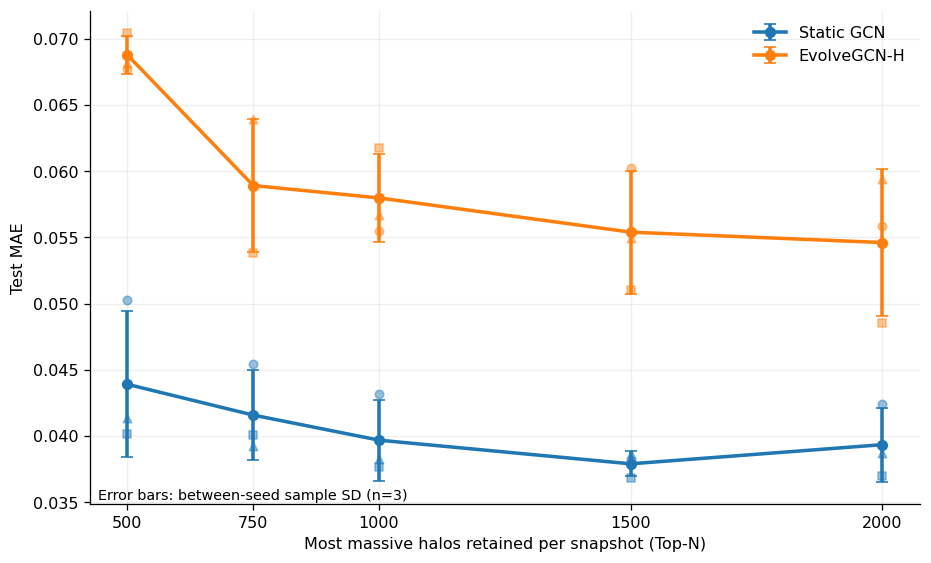

In [5]:
fig, ax = plt.subplots(figsize=(8.2, 5.0))
for model in MODEL_SPECS:
    model_data = test_metrics.query('Model == @model')
    grouped = model_data.groupby('Top-N')['mae'].agg(['mean', lambda x: x.std(ddof=1)]).reindex(TOP_NS)
    grouped.columns = ['mean', 'sd']
    for seed, marker in zip(SEEDS, ['o', 's', '^']):
        points = model_data.query('Seed == @seed').set_index('Top-N').reindex(TOP_NS)
        ax.scatter(TOP_NS, points['mae'], color=COLORS[model], marker=marker, s=28, alpha=0.45, zorder=2)
    ax.errorbar(TOP_NS, grouped['mean'], yerr=grouped['sd'], color=COLORS[model], marker='o', linewidth=2.2, capsize=4, label=model, zorder=3)
ax.set(xlabel='Most massive halos retained per snapshot (Top-N)', ylabel='Test MAE', xticks=TOP_NS)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
ax.text(0.01, 0.01, 'Error bars: between-seed sample SD (n=3)', transform=ax.transAxes, fontsize=9)
fig.patch.set_alpha(0); ax.set_facecolor('none'); fig.tight_layout()
display(fig); plt.close(fig)

In [6]:
marginal_rows = []
for model in MODEL_SPECS:
    means = summary.query('Model == @model').set_index('Top-N')['Mean_Test_MAE']
    for before, after in zip(TOP_NS[:-1], TOP_NS[1:]):
        delta = means.loc[after] - means.loc[before]
        marginal_rows.append({'Model': model, 'From Top-N': before, 'To Top-N': after, 'Mean MAE before': means.loc[before], 'Mean MAE after': means.loc[after], 'Delta MAE': delta, 'Relative change (%)': 100 * delta / means.loc[before]})
marginal_gains = pd.DataFrame(marginal_rows)
display(marginal_gains.style.format({'Mean MAE before': '{:.6f}', 'Mean MAE after': '{:.6f}', 'Delta MAE': '{:+.6f}', 'Relative change (%)': '{:+.2f}%'}))

,Model,From Top-N,To Top-N,Mean MAE before,Mean MAE after,Delta MAE,Relative change (%)
0,Static GCN,500,750,0.043894,0.041569,-0.002325,-5.30%
1,Static GCN,750,1000,0.041569,0.039674,-0.001895,-4.56%
2,Static GCN,1000,1500,0.039674,0.037887,-0.001787,-4.50%
3,Static GCN,1500,2000,0.037887,0.039333,+0.001447,+3.82%
4,EvolveGCN-H,500,750,0.068779,0.058916,-0.009863,-14.34%
5,EvolveGCN-H,750,1000,0.058916,0.057976,-0.000940,-1.60%
6,EvolveGCN-H,1000,1500,0.057976,0.055392,-0.002584,-4.46%
7,EvolveGCN-H,1500,2000,0.055392,0.054607,-0.000786,-1.42%


# 6 — Prediction Quality: True vs Predicted $\Omega_m$

Parity panels use the predeclared canonical seed 42 and never mix test populations across seeds. The identity line marks perfect predictions; vertical compression toward the center indicates a narrower predicted range than the target range. Top750 remains represented in every quantitative table.

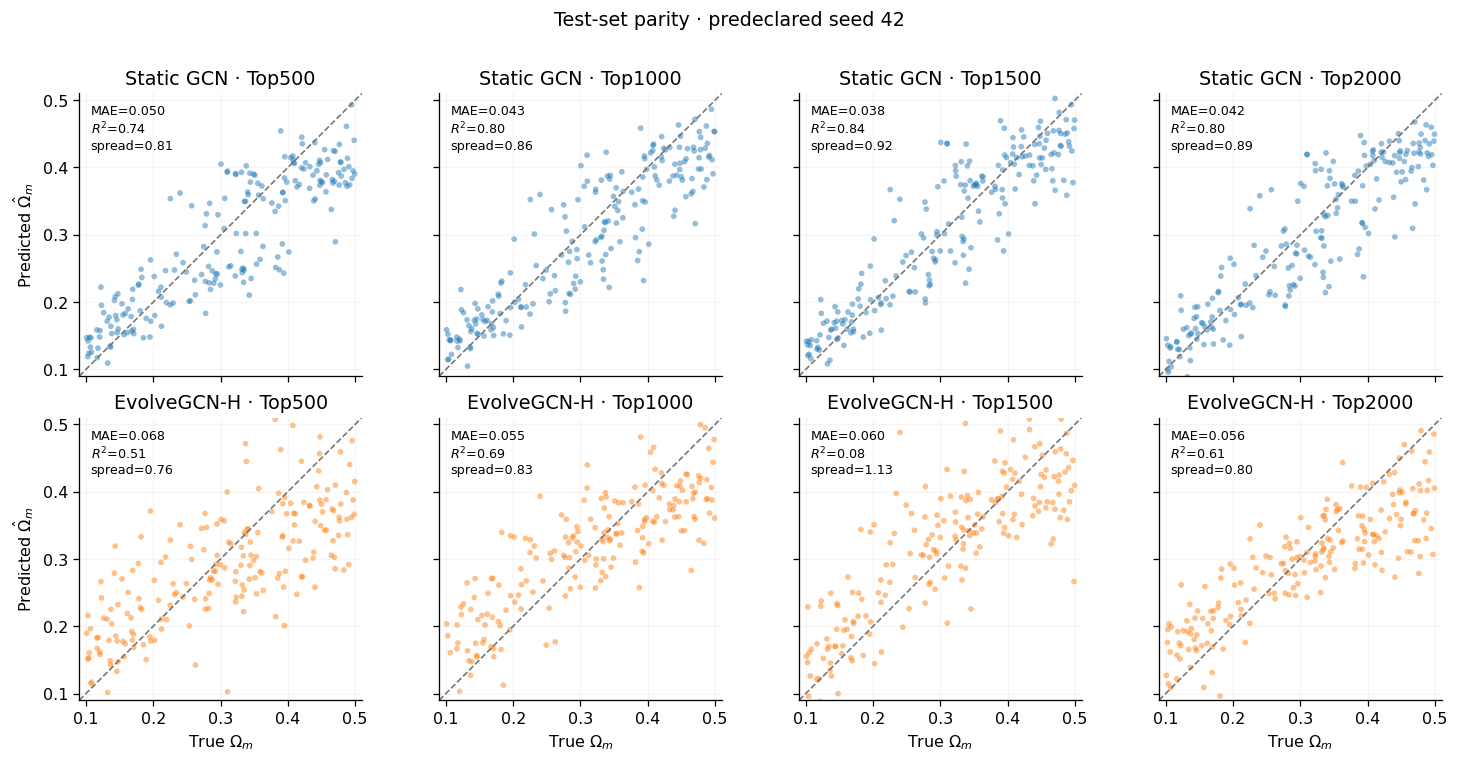

In [7]:
def test_frame(model, top_n, seed):
    return predictions.query("Partition == 'test' and Model == @model and Top_N == @top_n and Seed == @seed").copy()

def parity_figure(seed):
    shown_top = [500, 1000, 1500, 2000]
    fig, axes = plt.subplots(2, 4, figsize=(13.2, 6.5), sharex=True, sharey=True)
    limits = (0.09, 0.51)
    for row, model in enumerate(MODEL_SPECS):
        for col, top_n in enumerate(shown_top):
            ax = axes[row, col]; data = test_frame(model, top_n, seed)
            truth, pred = data['true_omega_m'], data['pred_omega_m']
            met = regression_metrics(data); ratio = pred.std(ddof=1) / truth.std(ddof=1)
            ax.scatter(truth, pred, s=13, alpha=0.48, color=COLORS[model], edgecolors='none')
            ax.plot(limits, limits, linestyle='--', color='0.45', linewidth=1)
            ax.set(xlim=limits, ylim=limits, aspect='equal', title=f'{model} · Top{top_n}')
            ax.text(0.04, 0.96, f"MAE={met['mae']:.3f}\n$R^2$={met['r2']:.2f}\nspread={ratio:.2f}", transform=ax.transAxes, va='top', fontsize=8)
            ax.grid(alpha=0.12); ax.set_facecolor('none')
    for ax in axes[-1]: ax.set_xlabel(r'True $\Omega_m$')
    for ax in axes[:, 0]: ax.set_ylabel(r'Predicted $\hat{\Omega}_m$')
    fig.suptitle(f'Test-set parity · predeclared seed {seed}', y=1.01)
    fig.patch.set_alpha(0); fig.tight_layout()
    return fig

fig = parity_figure(CANONICAL_VISUAL_SEED)
display(fig); plt.close(fig)

# 7 — Residual and Regression-to-the-Mean Analysis

Residual is $\hat{\Omega}_m-\Omega_m$. Positive residuals at low true values and negative residuals at high true values diagnose regression toward the mean. The endpoint comparison asks whether Top2000 reduces this pattern relative to Top500.

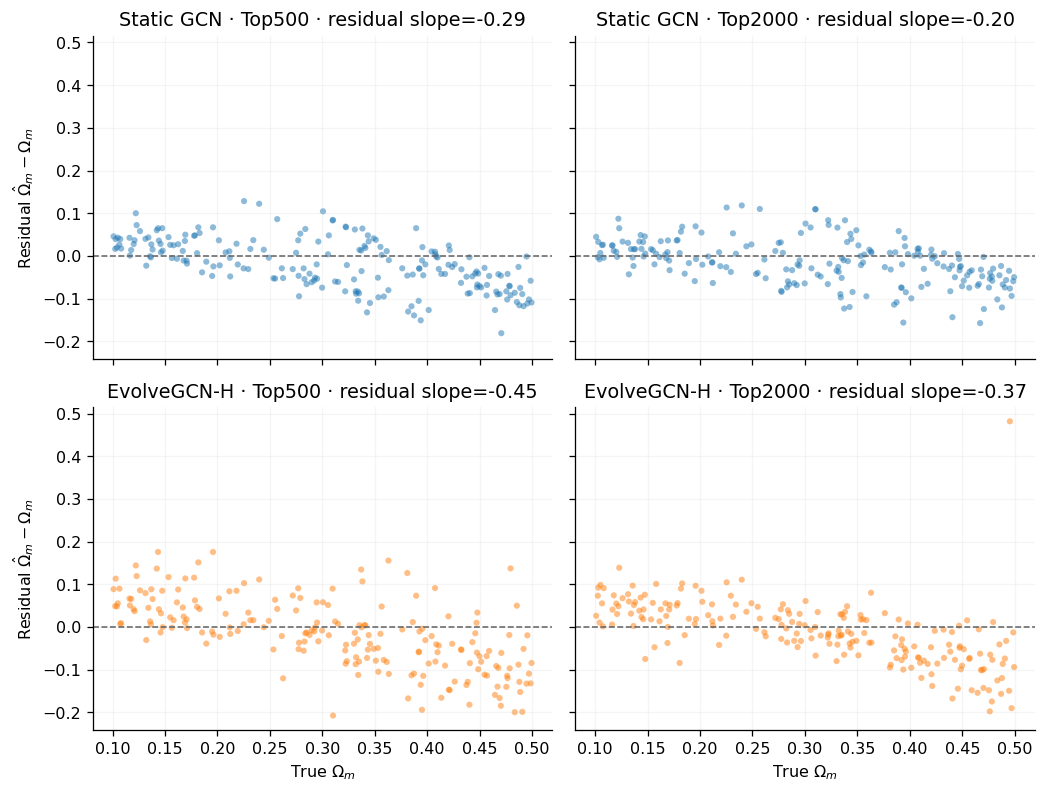

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.0), sharex=True, sharey=True)
for row, model in enumerate(MODEL_SPECS):
    for col, top_n in enumerate([500, 2000]):
        ax = axes[row, col]; data = test_frame(model, top_n, CANONICAL_VISUAL_SEED)
        residual = data['pred_omega_m'] - data['true_omega_m']
        ax.scatter(data['true_omega_m'], residual, s=15, alpha=0.5, color=COLORS[model], edgecolors='none')
        ax.axhline(0, linestyle='--', color='0.4', linewidth=1)
        coefficient = np.polyfit(data['true_omega_m'], residual, 1)[0]
        ax.set_title(f'{model} · Top{top_n} · residual slope={coefficient:.2f}')
        ax.grid(alpha=0.12); ax.set_facecolor('none')
for ax in axes[-1]: ax.set_xlabel(r'True $\Omega_m$')
for ax in axes[:, 0]: ax.set_ylabel(r'Residual $\hat{\Omega}_m-\Omega_m$')
fig.patch.set_alpha(0); fig.tight_layout()
display(fig); plt.close(fig)

# 8 — Prediction-Spread / Collapse Analysis

A model can attain non-trivial MAE while predicting an overly narrow target range. The study-specific spread ratio, $s(\hat{\Omega}_m)/s(\Omega_m)$, quantifies this compression: values substantially below one indicate prediction compression; they do not by themselves imply complete model collapse.

In [9]:
collapse_rows = []
for model in MODEL_SPECS:
    for top_n in TOP_NS:
        for seed in SEEDS:
            data = test_frame(model, top_n, seed)
            truth, pred = data['true_omega_m'], data['pred_omega_m']
            collapse_rows.append({'Model': model, 'Top-N': top_n, 'Seed': seed, 'True mean': truth.mean(), 'Predicted mean': pred.mean(), 'Bias': (pred-truth).mean(), 'True sample SD': truth.std(ddof=1), 'Predicted sample SD': pred.std(ddof=1), 'Spread ratio': pred.std(ddof=1)/truth.std(ddof=1), 'Test MAE': np.abs(pred-truth).mean()})
collapse_per_seed = pd.DataFrame(collapse_rows)
collapse_summary = collapse_per_seed.groupby(['Model', 'Top-N'], sort=False).agg(**{
    'Mean spread ratio': ('Spread ratio', 'mean'), 'Sample SD spread ratio': ('Spread ratio', lambda x: x.std(ddof=1)),
    'Mean bias': ('Bias', 'mean'), 'Sample SD bias': ('Bias', lambda x: x.std(ddof=1)), 'Mean Test MAE': ('Test MAE', 'mean'),
}).reset_index()
display(collapse_summary.style.format({c: '{:.6f}' for c in collapse_summary.columns if c not in ('Model', 'Top-N')}))

,Model,Top-N,Mean spread ratio,Sample SD spread ratio,Mean bias,Sample SD bias,Mean Test MAE
0,Static GCN,500,0.831769,0.023736,-0.005271,0.011631,0.043894
1,Static GCN,750,0.867642,0.054136,-0.000690,0.011536,0.041569
2,Static GCN,1000,0.855344,0.024906,-0.001966,0.010026,0.039674
3,Static GCN,1500,0.870902,0.044981,0.002156,0.003763,0.037887
4,Static GCN,2000,0.874061,0.039594,-0.003382,0.009734,0.039333
5,EvolveGCN-H,500,0.868683,0.152668,0.004072,0.021433,0.068779
6,EvolveGCN-H,750,0.897597,0.073387,-0.000753,0.006134,0.058916
7,EvolveGCN-H,1000,0.887988,0.075180,0.010347,0.013079,0.057976
8,EvolveGCN-H,1500,0.932660,0.183853,0.000157,0.007400,0.055392
9,EvolveGCN-H,2000,0.830670,0.047799,-0.003228,0.014343,0.054607


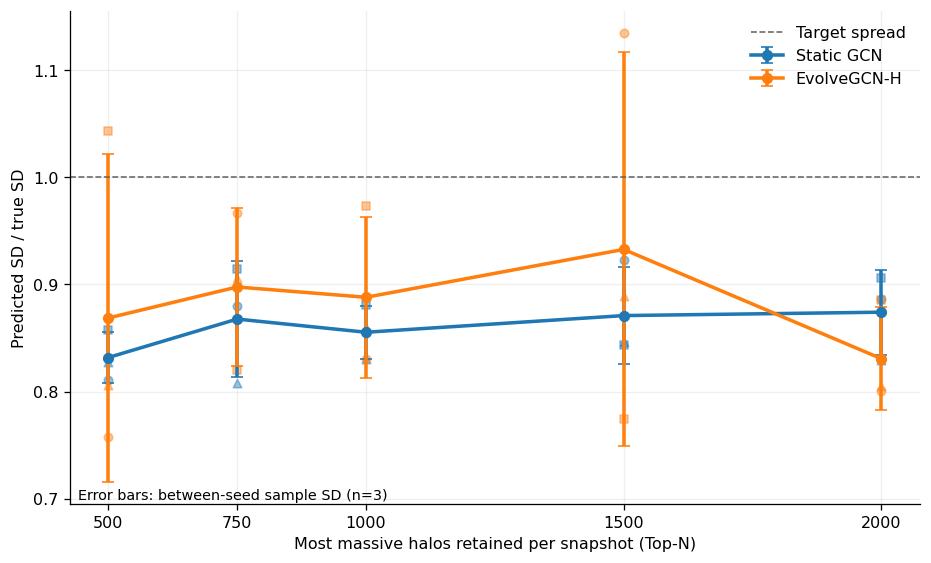

In [10]:
fig, ax = plt.subplots(figsize=(8.2, 5.0))
for model in MODEL_SPECS:
    model_data = collapse_per_seed.query('Model == @model')
    grouped = model_data.groupby('Top-N')['Spread ratio'].agg(['mean', lambda x: x.std(ddof=1)]).reindex(TOP_NS)
    grouped.columns = ['mean', 'sd']
    for seed, marker in zip(SEEDS, ['o', 's', '^']):
        values = model_data.query('Seed == @seed').set_index('Top-N').reindex(TOP_NS)['Spread ratio']
        ax.scatter(TOP_NS, values, color=COLORS[model], marker=marker, s=28, alpha=0.45)
    ax.errorbar(TOP_NS, grouped['mean'], yerr=grouped['sd'], color=COLORS[model], marker='o', linewidth=2.2, capsize=4, label=model)
ax.axhline(1, linestyle='--', color='0.4', linewidth=1, label='Target spread')
ax.set(xlabel='Most massive halos retained per snapshot (Top-N)', ylabel=r'Predicted SD / true SD', xticks=TOP_NS)
ax.grid(alpha=0.2); ax.legend(frameon=False)
ax.text(0.01, 0.01, 'Error bars: between-seed sample SD (n=3)', transform=ax.transAxes, fontsize=9)
fig.patch.set_alpha(0); ax.set_facecolor('none'); fig.tight_layout()
display(fig); plt.close(fig)

# 9 — High-N Saturation: Top1500 vs Top2000

This matched-seed comparison is the direct high-N test. Positive $\Delta$MAE favors Top1500; negative $\Delta$MAE favors Top2000. With only three seeds, these differences are descriptive and are not significance tests.

In [11]:
paired_rows = []
for model in MODEL_SPECS:
    for seed in SEEDS:
        values = test_metrics.query("Model == @model and Seed == @seed and `Top-N` in [1500, 2000]").set_index('Top-N')['mae']
        delta = values.loc[2000] - values.loc[1500]
        paired_rows.append({'Model': model, 'Seed': seed, 'Top1500 Test MAE': values.loc[1500], 'Top2000 Test MAE': values.loc[2000], 'Delta MAE': delta, 'Winner': 'Top1500' if delta > 0 else 'Top2000' if delta < 0 else 'Tie'})
high_n_paired = pd.DataFrame(paired_rows)
high_n_summary_rows = []
for model in MODEL_SPECS:
    subset = high_n_paired.query('Model == @model')
    for top_n in [1500, 2000]:
        column = f'Top{top_n} Test MAE'
        values = subset[column]
        high_n_summary_rows.append({'Model': model, 'Top-N': top_n, 'Mean Test MAE': values.mean(), 'Sample SD Test MAE': values.std(ddof=1), 'Matched-seed wins': int((subset['Winner'] == f'Top{top_n}').sum())})
high_n_summary = pd.DataFrame(high_n_summary_rows)
display(high_n_paired.style.format({'Top1500 Test MAE': '{:.6f}', 'Top2000 Test MAE': '{:.6f}', 'Delta MAE': '{:+.6f}'}))
display(high_n_summary.style.format({'Mean Test MAE': '{:.6f}', 'Sample SD Test MAE': '{:.6f}'}))

,Model,Seed,Top1500 Test MAE,Top2000 Test MAE,Delta MAE,Winner
0,Static GCN,42,0.038196,0.042387,+0.004191,Top1500
1,Static GCN,123,0.036829,0.036936,+0.000107,Top1500
2,Static GCN,2025,0.038635,0.038677,+0.000043,Top1500
3,EvolveGCN-H,42,0.060259,0.055879,-0.004379,Top2000
4,EvolveGCN-H,123,0.050986,0.048521,-0.002465,Top2000
5,EvolveGCN-H,2025,0.054933,0.059419,+0.004487,Top1500


,Model,Top-N,Mean Test MAE,Sample SD Test MAE,Matched-seed wins
0,Static GCN,1500,0.037887,0.000942,3
1,Static GCN,2000,0.039333,0.002784,0
2,EvolveGCN-H,1500,0.055392,0.004653,1
3,EvolveGCN-H,2000,0.054607,0.005560,2


# 10 — Scientific Interpretation

The next cell separates measured observations from hypotheses. Explanations involving lower-mass signal strength, mean-pooling dilution, message-passing capacity, temporal aggregation, or noisy/redundant nodes remain hypotheses requiring controlled experiments.

In [12]:
static = summary.query("Model == 'Static GCN'").set_index('Top-N')
evolve = summary.query("Model == 'EvolveGCN-H'").set_index('Top-N')
spread = collapse_summary.set_index(['Model', 'Top-N'])
static_wins = high_n_paired.query("Model == 'Static GCN'")['Winner'].value_counts().to_dict()
evolve_wins = high_n_paired.query("Model == 'EvolveGCN-H'")['Winner'].value_counts().to_dict()
display(Markdown(f"""
### What the data show

- Static GCN mean MAE improves from **{static.loc[500, 'Mean_Test_MAE']:.6f}** at Top500 to its minimum **{static.loc[1500, 'Mean_Test_MAE']:.6f}** at Top1500, then rises to **{static.loc[2000, 'Mean_Test_MAE']:.6f}**. Top1500 wins {static_wins.get('Top1500', 0)}/3 matched high-N seeds.
- EvolveGCN-H improves strongly from **{evolve.loc[500, 'Mean_Test_MAE']:.6f}** at Top500 to **{evolve.loc[2000, 'Mean_Test_MAE']:.6f}** at Top2000. The Top1500→Top2000 mean gain is small and seed-dependent: Top2000 wins {evolve_wins.get('Top2000', 0)}/3 seeds.
- The architectures respond differently: Static is consistently more accurate here and has a clear high-N minimum, while Evolve remains more seed-sensitive and continues a small mean improvement at Top2000.
- Mean spread ratio changes from **{spread.loc[('Static GCN', 500), 'Mean spread ratio']:.3f}** to **{spread.loc[('Static GCN', 2000), 'Mean spread ratio']:.3f}** for Static and from **{spread.loc[('EvolveGCN-H', 500), 'Mean spread ratio']:.3f}** to **{spread.loc[('EvolveGCN-H', 2000), 'Mean spread ratio']:.3f}** for Evolve. Ratios below one and the signed residual pattern indicate persistent prediction compression/regression toward the mean, not constant-output collapse.

### What could explain it

Additional lower-mass halos may carry weaker incremental signal; pooling or model capacity may limit how effectively added nodes are used; temporal aggregation may constrain EvolveGCN-H; or larger graphs may add redundancy/noise. This experiment does not distinguish among these mechanisms.
"""))


### What the data show

- Static GCN mean MAE improves from **0.043894** at Top500 to its minimum **0.037887** at Top1500, then rises to **0.039333**. Top1500 wins 3/3 matched high-N seeds.
- EvolveGCN-H improves strongly from **0.068779** at Top500 to **0.054607** at Top2000. The Top1500→Top2000 mean gain is small and seed-dependent: Top2000 wins 2/3 seeds.
- The architectures respond differently: Static is consistently more accurate here and has a clear high-N minimum, while Evolve remains more seed-sensitive and continues a small mean improvement at Top2000.
- Mean spread ratio changes from **0.832** to **0.874** for Static and from **0.869** to **0.831** for Evolve. Ratios below one and the signed residual pattern indicate persistent prediction compression/regression toward the mean, not constant-output collapse.

### What could explain it

Additional lower-mass halos may carry weaker incremental signal; pooling or model capacity may limit how effectively added nodes are used; temporal aggregation may constrain EvolveGCN-H; or larger graphs may add redundancy/noise. This experiment does not distinguish among these mechanisms.


# 11 — Limitations and What This Experiment Does Not Prove

The experiment establishes performance trends for these architectures, features, graph construction, pooling choices, snapshots, and three seeds. It does **not** show that halos below Top1500 contain no cosmological information, prove that mean pooling causes saturation, or establish statistical significance. Top-N also changes graph composition and message-passing context together, so mechanisms require separate ablations.

# 12 — Next Research Questions

The most direct follow-ups are a non-graph raw-halo/DeepSets baseline, a mean-versus-mean+max pooling ablation, and a 2/3/4/5-snapshot temporal ablation. These would test whether the apparent saturation comes from the data representation, graph readout, or temporal architecture.

# Supplementary Parity Figures — Seeds 123 and 2025

These predeclared supplementary views prevent the seed-42 presentation figure from becoming a cherry-picked visual summary. Each panel still contains only one seed-specific test population.

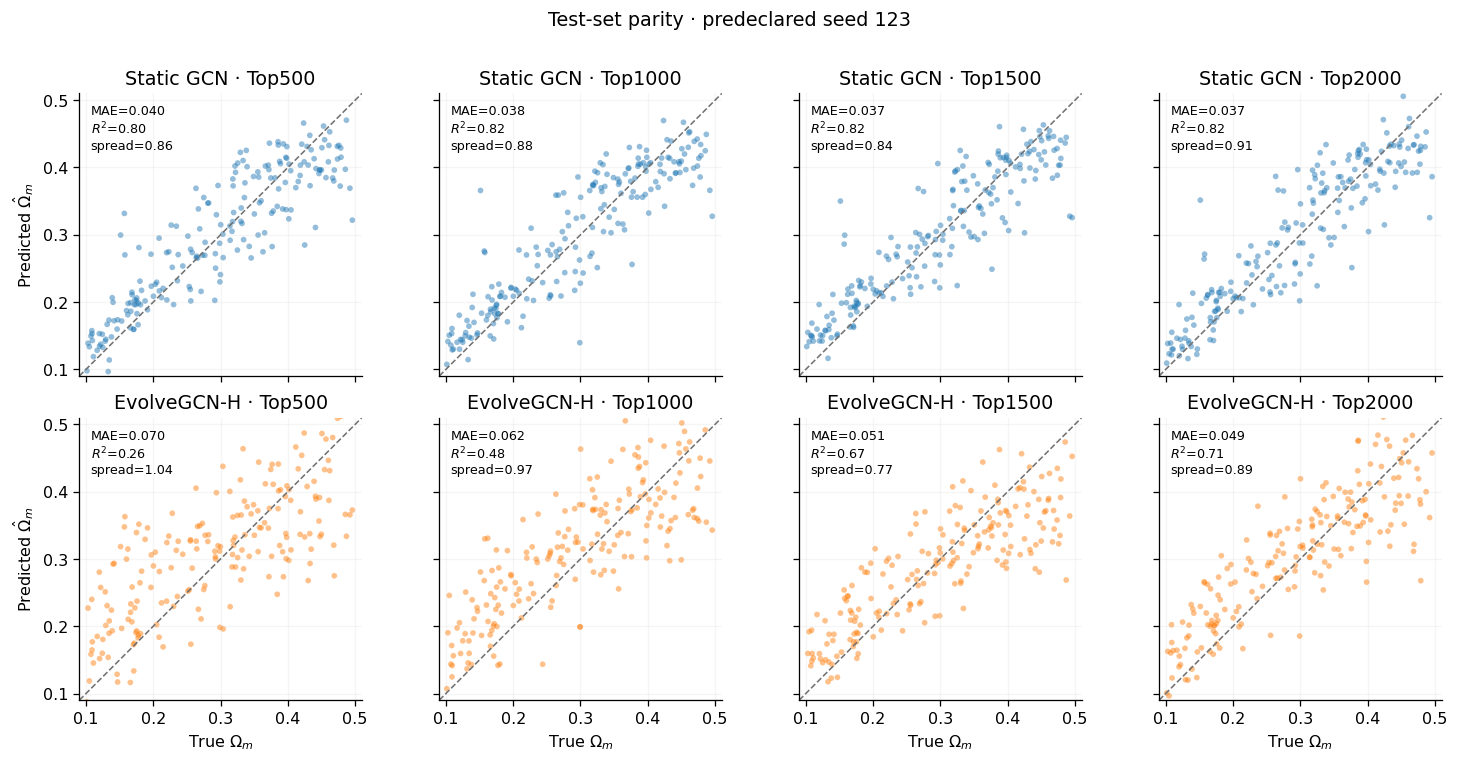

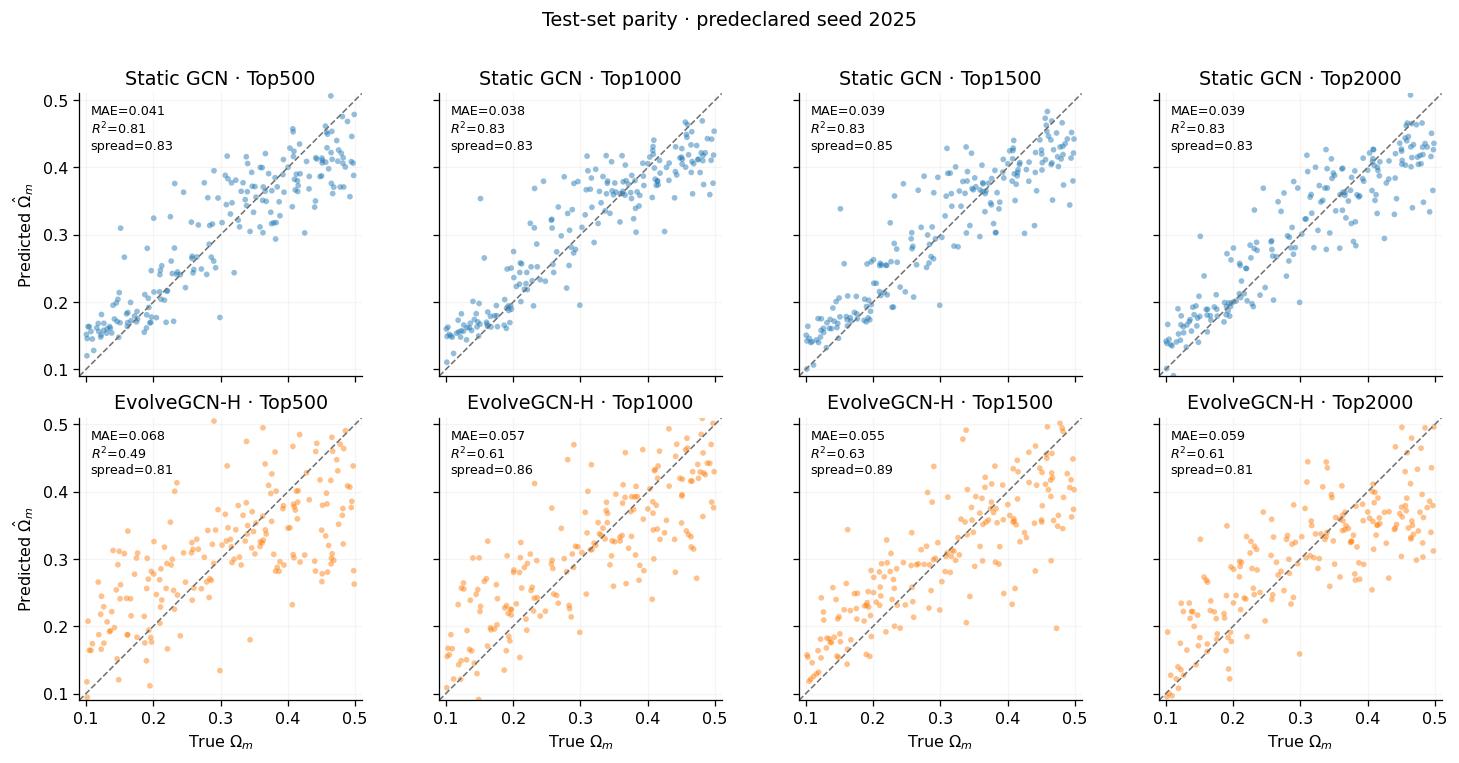

In [13]:
for seed in [123, 2025]:
    fig = parity_figure(seed)
    display(fig); plt.close(fig)

# 13 — Compact Reproducibility Appendix

The following cell exports the analysis-derived tables and transparent PNG figures. It also records Git state without treating archival cleanliness as scientific validity. Top1000 retains a historical stale preprocessing-version label despite validated effective fields; Top2000 used a dedicated builder; and some experiment artifacts are currently untracked. None changed the validated scientific matrix.

In [14]:
generalization = metrics_long.groupby(['Model', 'Top-N', 'Partition'], sort=False)['mae'].agg(['mean', lambda x: x.std(ddof=1)]).reset_index()
generalization.columns = ['Model', 'Top-N', 'Partition', 'Mean MAE', 'Sample SD MAE']
generalization = generalization.pivot(index=['Model', 'Top-N'], columns='Partition', values=['Mean MAE', 'Sample SD MAE']).reset_index()
generalization.columns = [' '.join(str(part) for part in column if part).strip() if isinstance(column, tuple) else column for column in generalization.columns]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tables = {
    'table01_experiment_integrity.csv': integrity_table,
    'table02_main_performance.csv': main_performance,
    'table03_marginal_scaling_gains.csv': marginal_gains,
    'table04_prediction_collapse_per_seed.csv': collapse_per_seed,
    'table05_prediction_collapse_summary.csv': collapse_summary,
    'table06_top1500_vs_top2000.csv': high_n_paired,
    'table07_generalization.csv': generalization,
    'table08_run_provenance.csv': runs,
}
for filename, frame in tables.items():
    frame.to_csv(OUTPUT_DIR / filename, index=False)

fig = plt.figure(figsize=(8.2, 5.0)); ax = fig.add_subplot(111)
for model in MODEL_SPECS:
    data = test_metrics.query('Model == @model'); grouped = data.groupby('Top-N')['mae'].agg(['mean', lambda x: x.std(ddof=1)]).reindex(TOP_NS); grouped.columns=['mean','sd']
    for seed, marker in zip(SEEDS, ['o','s','^']): ax.scatter(TOP_NS, data.query('Seed == @seed').set_index('Top-N').reindex(TOP_NS)['mae'], color=COLORS[model], marker=marker, s=28, alpha=.45)
    ax.errorbar(TOP_NS, grouped['mean'], yerr=grouped['sd'], color=COLORS[model], marker='o', linewidth=2.2, capsize=4, label=model)
ax.set(xlabel='Most massive halos retained per snapshot (Top-N)', ylabel='Test MAE', xticks=TOP_NS); ax.grid(alpha=.2); ax.legend(frameon=False); ax.text(.01,.01,'Error bars: between-seed sample SD (n=3)',transform=ax.transAxes,fontsize=9); fig.patch.set_alpha(0); ax.set_facecolor('none'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'fig01_test_mae_vs_topn.png', transparent=True, bbox_inches='tight'); plt.close(fig)

for seed, filename in [(42,'fig02_parity_seed42.png'),(123,'fig02b_parity_seed123.png'),(2025,'fig02c_parity_seed2025.png')]:
    fig=parity_figure(seed); fig.savefig(OUTPUT_DIR/filename, transparent=True, bbox_inches='tight'); plt.close(fig)

fig, axes = plt.subplots(2,2,figsize=(9.2,7.0),sharex=True,sharey=True)
for row,model in enumerate(MODEL_SPECS):
    for col,top_n in enumerate([500,2000]):
        ax=axes[row,col]; data=test_frame(model,top_n,42); residual=data['pred_omega_m']-data['true_omega_m']; ax.scatter(data['true_omega_m'],residual,s=15,alpha=.5,color=COLORS[model],edgecolors='none'); ax.axhline(0,linestyle='--',color='0.4',linewidth=1); slope=np.polyfit(data['true_omega_m'],residual,1)[0]; ax.set_title(f'{model} · Top{top_n} · residual slope={slope:.2f}'); ax.grid(alpha=.12); ax.set_facecolor('none')
for ax in axes[-1]: ax.set_xlabel(r'True $\Omega_m$')
for ax in axes[:,0]: ax.set_ylabel(r'Residual $\hat{\Omega}_m-\Omega_m$')
fig.patch.set_alpha(0); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'fig03_residual_vs_truth_seed42.png',transparent=True,bbox_inches='tight'); plt.close(fig)

fig,ax=plt.subplots(figsize=(8.2,5.0))
for model in MODEL_SPECS:
    data=collapse_per_seed.query('Model == @model'); grouped=data.groupby('Top-N')['Spread ratio'].agg(['mean',lambda x:x.std(ddof=1)]).reindex(TOP_NS); grouped.columns=['mean','sd']
    for seed,marker in zip(SEEDS,['o','s','^']): ax.scatter(TOP_NS,data.query('Seed == @seed').set_index('Top-N').reindex(TOP_NS)['Spread ratio'],color=COLORS[model],marker=marker,s=28,alpha=.45)
    ax.errorbar(TOP_NS,grouped['mean'],yerr=grouped['sd'],color=COLORS[model],marker='o',linewidth=2.2,capsize=4,label=model)
ax.axhline(1,linestyle='--',color='.4',linewidth=1,label='Target spread'); ax.set(xlabel='Most massive halos retained per snapshot (Top-N)',ylabel='Predicted SD / true SD',xticks=TOP_NS); ax.grid(alpha=.2); ax.legend(frameon=False); ax.text(.01,.01,'Error bars: between-seed sample SD (n=3)',transform=ax.transAxes,fontsize=9); fig.patch.set_alpha(0); ax.set_facecolor('none'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/'fig04_prediction_spread_ratio_vs_topn.png',transparent=True,bbox_inches='tight'); plt.close(fig)

branch = subprocess.check_output(['git', 'branch', '--show-current'], cwd=REPO, text=True).strip()
head = subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=REPO, text=True).strip()
git_status = subprocess.check_output(['git', 'status', '--short'], cwd=REPO, text=True).rstrip()
provenance = pd.DataFrame([{'Branch': branch, 'HEAD': head, 'Execution UTC': datetime.now(timezone.utc).isoformat(), 'Expected runs': 30, 'Validated runs': len(runs), 'Canonical visual seed': CANONICAL_VISUAL_SEED, 'Sample SD': 'ddof=1 (n-1)', 'Output directory': str(OUTPUT_DIR.relative_to(REPO))}])
dataset_provenance = runs[['Top-N', 'Dataset', 'Dataset SHA binding']].drop_duplicates().sort_values('Top-N').reset_index(drop=True)
display(provenance)
display(dataset_provenance)
print('Full experiment names and split-manifest paths: table08_run_provenance.csv')
print('Git status --short (dirty state is archival context, not a scientific failure):')
print(git_status or '(clean)')
print(f'Exported {len(tables)} tables and 6 figures to {OUTPUT_DIR}')

,Branch,HEAD,Execution UTC,Expected runs,Validated runs,Canonical visual seed,Sample SD,Output directory
0,thesis-sparse-integrity-hardening,53a748764ba29a9df2107b3640d3871fd887de34,2026-08-23T21:15:37.579116+00:00,30,30,42,ddof=1 (n-1),notebooks/visualization/outputs/12_u1000_topn_...


,Top-N,Dataset,Dataset SHA binding
0,500,data/processed/temporal_1000u_none_top500_peri...,8672e3f7897507185578a138021e9eaea096219cf33a2e...
1,750,data/processed/temporal_1000u_none_top750_peri...,9b988067206cd20b5b9adbbddda193d651f8399fe26ca3...
2,1000,data/processed/temporal_1000u_none_top1000_per...,6a794c38216175212ec969283fdbd214bcdc64caecde78...
3,1500,data/processed/temporal_1000u_none_top1500_per...,ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23...
4,2000,data/processed/temporal_1000u_none_top2000_per...,b4258f4c95b15c4626609e1de4b1784d8120fe36bfd43d...


Full experiment names and split-manifest paths: table08_run_provenance.csv
Git status --short (dirty state is archival context, not a scientific failure):
 M .gitignore
 M configs/experiment_families/u1000_top500_train700_static_gcn.json
?? configs/experiment_families/u1000_top2000_train700_evolvegcn_h.json
?? configs/experiment_families/u1000_top2000_train700_static_gcn.json
?? configs/splits/u1000_top2000_none_k8_sparse/
?? experiments/evolvegcn_h_u1000_top2000_sparse_train700_seed123_none_h32_l2_mean_temporal_mean_linear/
?? experiments/evolvegcn_h_u1000_top2000_sparse_train700_seed2025_none_h32_l2_mean_temporal_mean_linear/
?? experiments/evolvegcn_h_u1000_top2000_sparse_train700_seed42_none_h32_l2_mean_temporal_mean_linear/
?? experiments/evolvegcn_h_u1000_top500_sparse_train700_seed123_none_h32_l2_mean_temporal_mean_linear/
?? experiments/evolvegcn_h_u1000_top500_sparse_train700_seed2025_none_h32_l2_mean_temporal_mean_linear/
?? experiments/evolvegcn_h_u1000_top500_sparse_train70

<details>
<summary><strong>Full per-seed prediction-spread diagnostics and run provenance</strong></summary>

The executed outputs above are exported as machine-readable CSVs. `table04_prediction_collapse_per_seed.csv` contains all 30 per-seed diagnostics; `table01_experiment_integrity.csv` and the in-memory `runs` table retain experiment names, dataset paths/SHA bindings, and split-manifest paths. Metrics use MAE $=n^{-1}\sum|\hat y-y|$, MSE $=n^{-1}\sum(\hat y-y)^2$, RMSE $=\sqrt{\mathrm{MSE}}$, and $R^2=1-\sum(\hat y-y)^2/\sum(y-\bar y)^2$. Cross-seed SD uses `ddof=1`.

</details>